In [1]:
# --- Celda de arranque ---
import pandas as pd
import numpy as np
from pathlib import Path

def encontrar_raiz_proyecto(marcador="requirements.txt"):
    actual = Path.cwd()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / marcador).exists():
            return carpeta
    raise FileNotFoundError(f"No encontré '{marcador}' subiendo desde {actual}")

RAIZ = encontrar_raiz_proyecto()
print("Raíz del proyecto:", RAIZ)

def calcular_metricas(y_real, y_pred, nombre):
    y_real, y_pred = np.asarray(y_real), np.asarray(y_pred)
    error = y_real - y_pred
    mae = np.abs(error).mean()
    rmse = np.sqrt((error ** 2).mean())
    mape = (np.abs(error) / y_real).mean() * 100
    print(f"{nombre:25s} MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape:6.2f}%")
    return mae, rmse, mape

Raíz del proyecto: C:\Users\mgdbj\xm-spot-price-predictor


In [2]:
# --- Celda 1: Cargar features y armar X / y ---
df_train = pd.read_csv(RAIZ / "data" / "processed" / "dataset_features_2019_2025.csv", parse_dates=["fecha_hora"])
df_test = pd.read_csv(RAIZ / "data" / "processed" / "dataset_features_2026.csv", parse_dates=["fecha_hora"])

# Excluidas a propósito, no por descuido:
# - demanda, generacion: se determinan al mismo tiempo que el precio (no se
#   conocerían de antemano en un pronóstico real de 24-72h)
# - fecha_hora, anio, mes, hora, dia_semana, dia_anio (crudos): ya están
#   representados por sus versiones seno/coseno, que capturan mejor la
#   ciclicidad; dejar ambas versiones solo reparte la importancia entre
#   columnas redundantes cuando lleguemos a SHAP
columnas_excluir = ["fecha_hora", "precio_bolsa", "demanda", "generacion",
                     "anio", "mes", "hora", "dia_semana", "dia_anio"]
columnas_features = [c for c in df_train.columns if c not in columnas_excluir]

X_train = df_train[columnas_features]
y_train = np.log(df_train["precio_bolsa"])  # mismo log-transform que Prophet v3, por consistencia metodológica

X_test = df_test[columnas_features]
y_test = df_test["precio_bolsa"]  # se compara en escala real, no en log

print("Features usadas:", columnas_features)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

Features usadas: ['volumen_embalses', 'aportes_hidricos', 'es_pandemia', 'oni', 'precio_lag24h', 'precio_lag168h', 'precio_media_24h', 'precio_media_7d', 'precio_media_30d', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'dia_anio_sin', 'dia_anio_cos', 'volumen_embalses_delta_1d', 'volumen_embalses_delta_7d', 'volumen_embalses_media_7d', 'volumen_embalses_media_30d', 'volumen_embalses_vs_media30d', 'aportes_hidricos_delta_1d', 'aportes_hidricos_delta_7d', 'aportes_hidricos_media_7d', 'aportes_hidricos_media_30d', 'aportes_hidricos_vs_media30d', 'precio_std_24h', 'precio_std_7d', 'precio_rango_24h', 'ratio_volatilidad', 'demanda_lag24h', 'demanda_lag48h', 'demanda_lag72h', 'demanda_media_24h']

Train: (60625, 33) | Test: (5208, 33)


In [3]:
# --- Celda 2: Entrenar XGBoost, configuración base (sin tunear todavía) ---
import xgboost as xgb

modelo_xgb = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

modelo_xgb.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


In [4]:
# --- Celda 3: Predecir sobre 2026 y evaluar contra persistencia ---
pred_log = modelo_xgb.predict(X_test)
y_pred = np.exp(pred_log)

print("Predicciones negativas:", (y_pred < 0).sum())

serie_precio = pd.concat([
    df_train[["fecha_hora", "precio_bolsa"]],
    df_test[["fecha_hora", "precio_bolsa"]]
]).sort_values("fecha_hora").reset_index(drop=True)
serie_precio["persistencia"] = serie_precio["precio_bolsa"].shift(24)
persistencia_test = serie_precio[serie_precio["fecha_hora"].isin(df_test["fecha_hora"])]["persistencia"].values

calcular_metricas(y_test, y_pred, "XGBoost (base, sin tunear)")
calcular_metricas(y_test, persistencia_test, "Persistencia")
print("\nReferencia -- Prophet final (datos corregidos): MAE 92.25 | RMSE 144.73 | MAPE 19.55%")

Predicciones negativas: 0
XGBoost (base, sin tunear) MAE:    66.51  RMSE:   107.93  MAPE:  17.93%
Persistencia              MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

Referencia -- Prophet final (datos corregidos): MAE 92.25 | RMSE 144.73 | MAPE 19.55%


In [5]:
# --- Diagnóstico: error por régimen de ONI, igual que se hizo con Prophet ---
resultado_xgb = df_test[["fecha_hora", "oni"]].copy()
resultado_xgb["y"] = y_test.values
resultado_xgb["yhat"] = y_pred
resultado_xgb["error_abs"] = (resultado_xgb["y"] - resultado_xgb["yhat"]).abs()

mediana_oni = resultado_xgb["oni"].median()
alto = resultado_xgb[resultado_xgb["oni"] >= mediana_oni]
bajo = resultado_xgb[resultado_xgb["oni"] < mediana_oni]

print(f"XGBoost -- Error medio con ONI alto (>= {mediana_oni:.2f}): {alto['error_abs'].mean():.2f}")
print(f"XGBoost -- Error medio con ONI bajo (< {mediana_oni:.2f}):  {bajo['error_abs'].mean():.2f}")
print(f"Razón alto/bajo: {alto['error_abs'].mean() / bajo['error_abs'].mean():.2f}x")
print("\nReferencia -- Prophet: 133.71 vs 26.13 (razón 5.1x)")

XGBoost -- Error medio con ONI alto (>= 0.50): 93.25
XGBoost -- Error medio con ONI bajo (< 0.50):  28.77
Razón alto/bajo: 3.24x

Referencia -- Prophet: 133.71 vs 26.13 (razón 5.1x)


In [6]:
# --- Grid search de XGBoost, validando con 2025 (no tocar 2026 todavía) ---
import itertools

train_gs = df_train[df_train["fecha_hora"] < "2025-01-01"]
valid_gs = df_train[df_train["fecha_hora"] >= "2025-01-01"]

X_train_gs = train_gs[columnas_features]
y_train_gs = np.log(train_gs["precio_bolsa"])
X_valid_gs = valid_gs[columnas_features]
y_valid_gs = valid_gs["precio_bolsa"]

print(f"Train GS: {len(train_gs)} | Valid GS: {len(valid_gs)}")

rejilla = {
    "max_depth": [3, 6, 9],
    "learning_rate": [0.01, 0.05, 0.1],
}
combinaciones = [dict(zip(rejilla.keys(), valores)) for valores in itertools.product(*rejilla.values())]

resultados_gs = []
for i, params in enumerate(combinaciones, 1):
    m = xgb.XGBRegressor(n_estimators=500, subsample=0.8, colsample_bytree=0.8,
                          random_state=42, **params)
    m.fit(X_train_gs, y_train_gs)
    pred = np.exp(m.predict(X_valid_gs))

    mae = np.abs(y_valid_gs.values - pred).mean()
    resultados_gs.append({**params, "mae": mae})
    print(f"[{i}/{len(combinaciones)}] {params} -> MAE {mae:.2f}")

df_gs_xgb = pd.DataFrame(resultados_gs).sort_values("mae").reset_index(drop=True)
df_gs_xgb

Train GS: 51865 | Valid GS: 8760


[1/9] {'max_depth': 3, 'learning_rate': 0.01} -> MAE 45.05


[2/9] {'max_depth': 3, 'learning_rate': 0.05} -> MAE 45.78


[3/9] {'max_depth': 3, 'learning_rate': 0.1} -> MAE 52.99


[4/9] {'max_depth': 6, 'learning_rate': 0.01} -> MAE 46.36


...

[6/9] {'max_depth': 6, 'learning_rate': 0.1} -> MAE 56.92


[7/9] {'max_depth': 9, 'learning_rate': 0.01} -> MAE 51.22


[8/9] {'max_depth': 9, 'learning_rate': 0.05} -> MAE 56.37


[9/9] {'max_depth': 9, 'learning_rate': 0.1} -> MAE 57.84


,max_depth,learning_rate,mae
0,3,0.01,45.054362
1,3,0.05,45.781544
2,6,0.01,46.356655
3,6,0.05,50.793256
4,9,0.01,51.217155
5,3,0.10,52.989373
6,9,0.05,56.366915
7,6,0.10,56.922381
8,9,0.10,57.841538


In [7]:
# --- Refinamiento (CORREGIDO): con el learning_rate que de verdad ganó ---
rejilla_fina = [1, 2, 3]

resultados_gs2 = []
for i, depth in enumerate(rejilla_fina, 1):
    m = xgb.XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=depth,
                          subsample=0.8, colsample_bytree=0.8, random_state=42)
    m.fit(X_train_gs, y_train_gs)
    pred = np.exp(m.predict(X_valid_gs))

    mae = np.abs(y_valid_gs.values - pred).mean()
    resultados_gs2.append({"max_depth": depth, "mae": mae})
    print(f"[{i}/{len(rejilla_fina)}] max_depth={depth} -> MAE {mae:.2f}")

df_gs_xgb2 = pd.DataFrame(resultados_gs2).sort_values("mae").reset_index(drop=True)
df_gs_xgb2

[1/3] max_depth=1 -> MAE 50.33


[2/3] max_depth=2 -> MAE 46.55


[3/3] max_depth=3 -> MAE 45.05


,max_depth,mae
0,3,45.054362
1,2,46.546310
2,1,50.327764


In [8]:
# --- Modelo XGBoost final: max_depth=3, learning_rate=0.01, sobre 2019-2025 completo ---
modelo_xgb_final = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

modelo_xgb_final.fit(X_train, y_train)  # X_train/y_train ya son 2019-2025 completo, de la Celda 1

pred_log_final = modelo_xgb_final.predict(X_test)
y_pred_final = np.exp(pred_log_final)

print("Predicciones negativas:", (y_pred_final < 0).sum())

calcular_metricas(y_test, y_pred_final, "XGBoost final (depth=3, lr=0.01)")
calcular_metricas(y_test, persistencia_test, "Persistencia")
print("\nReferencia -- Prophet final (datos corregidos): MAE 92.25 | RMSE 144.73 | MAPE 19.55%")

Predicciones negativas: 0
XGBoost final (depth=3, lr=0.01) MAE:    60.66  RMSE:   107.18  MAPE:  15.81%
Persistencia              MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

Referencia -- Prophet final (datos corregidos): MAE 92.25 | RMSE 144.73 | MAPE 19.55%


In [9]:
# --- Mismo diagnóstico de régimen, sobre el modelo final ---
resultado_xgb_final = df_test[["fecha_hora", "oni"]].copy()
resultado_xgb_final["y"] = y_test.values
resultado_xgb_final["yhat"] = y_pred_final
resultado_xgb_final["error_abs"] = (resultado_xgb_final["y"] - resultado_xgb_final["yhat"]).abs()

alto = resultado_xgb_final[resultado_xgb_final["oni"] >= mediana_oni]
bajo = resultado_xgb_final[resultado_xgb_final["oni"] < mediana_oni]

print(f"XGBoost final -- ONI alto: {alto['error_abs'].mean():.2f}  |  ONI bajo: {bajo['error_abs'].mean():.2f}  |  razón {alto['error_abs'].mean()/bajo['error_abs'].mean():.2f}x")

XGBoost final -- ONI alto: 86.83  |  ONI bajo: 23.73  |  razón 3.66x


In [10]:
# --- Confirmar la versión de XGBoost antes de usar SHAP ---
import xgboost
print("Versión de XGBoost:", xgboost.__version__)  # debe ser menor a 3.0.0

Versión de XGBoost: 2.1.4


In [11]:
# --- SHAP: explicabilidad del modelo XGBoost final ---
import shap

explainer = shap.TreeExplainer(modelo_xgb_final)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculados:", shap_values.shape)  # debería ser (5208, 15) -- una fila por hora de test, una columna por feature

C:\Users\mgdbj\xm-spot-price-predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values calculados: (5208, 33)


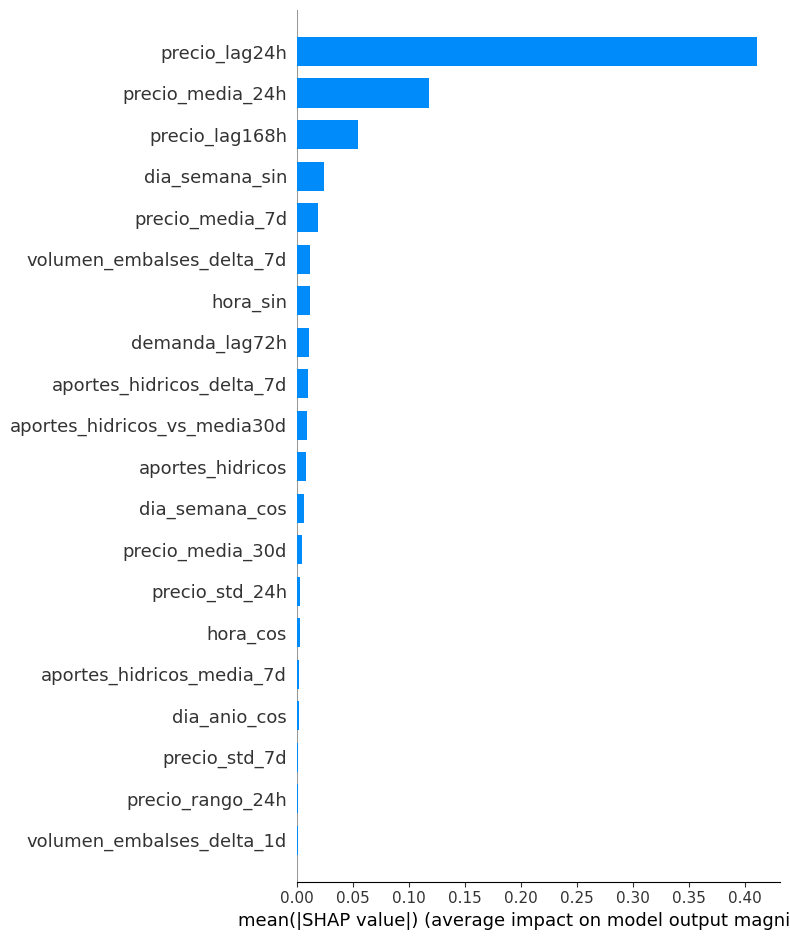

In [12]:
# --- Importancia global: qué variables más influyen, en promedio ---
# Este es el alcance que ya habían decidido -- importancia global, no
# exploración exhaustiva instancia por instancia.
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

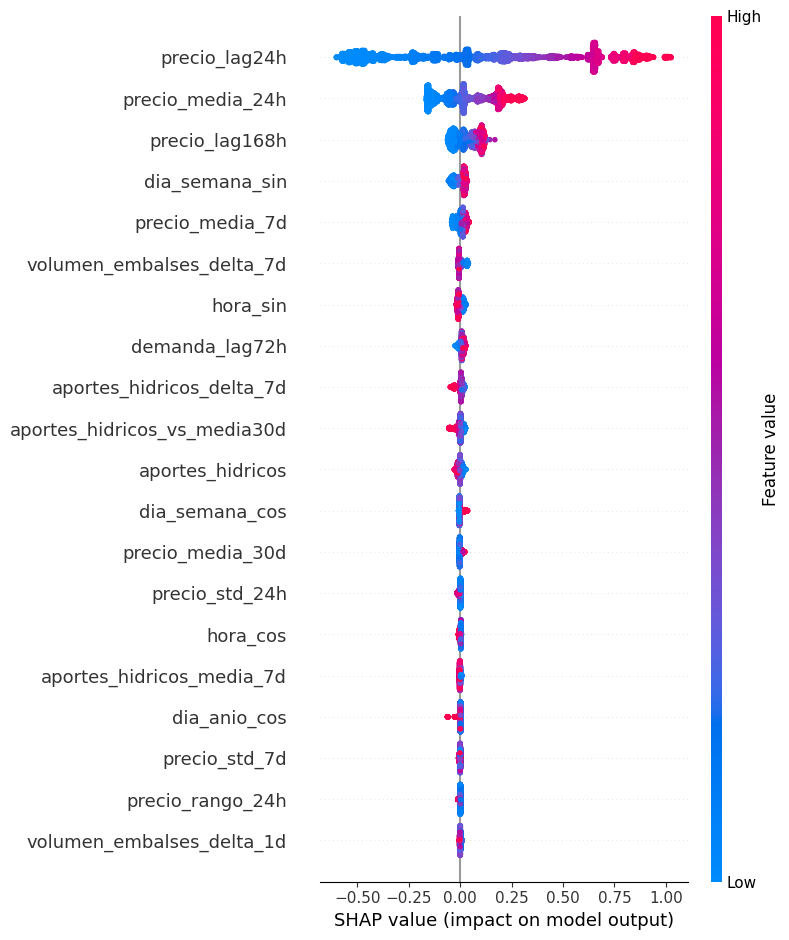

In [13]:
# --- Mismo análisis, pero mostrando también la DIRECCIÓN del efecto ---
# El gráfico de barras solo dice "qué tanto importa"; este además dice "en
# qué sentido" -- por ejemplo, si un ONI alto empuja el precio hacia arriba
# o hacia abajo, no solo que sea una variable relevante.
shap.summary_plot(shap_values, X_test, show=True)

In [14]:
# --- Celda: Armar la tabla comparativa real vs. predicho ---
comparacion = df_test[["fecha_hora", "precio_bolsa"]].copy()
comparacion["prediccion"] = y_pred_final
comparacion["error"] = comparacion["precio_bolsa"] - comparacion["prediccion"]
comparacion["error_pct"] = (comparacion["error"].abs() / comparacion["precio_bolsa"]) * 100

# Las últimas 48 horas (2 días) -- los datos más recientes que tienes, uno a
# uno, para ver casos concretos en vez de un promedio abstracto.
comparacion.tail(48)

,fecha_hora,precio_bolsa,prediccion,error,error_pct
5160,2026-08-04 00:00:00,1024.02798,847.973083,176.054897,17.192391
5161,2026-08-04 01:00:00,1021.02798,848.400879,172.627101,16.907186
5162,2026-08-04 02:00:00,1021.02798,839.353699,181.674281,17.793272
5163,2026-08-04 03:00:00,980.02798,838.885925,141.142055,14.401839
5164,2026-08-04 04:00:00,1018.22798,846.081238,172.146742,16.906503
5165,2026-08-04 05:00:00,1024.02798,853.715088,170.312892,16.631664
5166,2026-08-04 06:00:00,1024.02798,860.652588,163.375392,15.954192
5167,2026-08-04 07:00:00,980.02798,861.144348,118.883632,12.130637
5168,2026-08-04 08:00:00,686.89998,898.363098,-211.463118,30.785140
5169,2026-08-04 09:00:00,816.13198,939.085754,-122.953774,15.065428


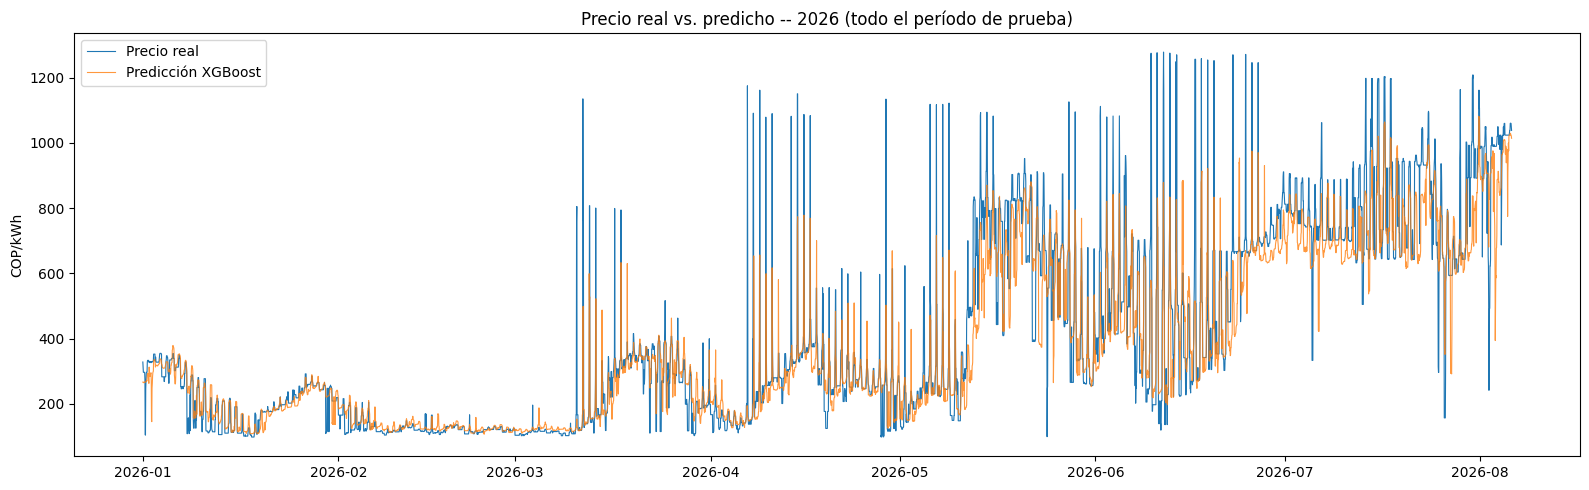

In [15]:
# --- Gráfica: todo 2026, real vs. predicho ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(comparacion["fecha_hora"], comparacion["precio_bolsa"], label="Precio real", linewidth=0.8)
ax.plot(comparacion["fecha_hora"], comparacion["prediccion"], label="Predicción XGBoost", linewidth=0.8, alpha=0.8)
ax.set_title("Precio real vs. predicho -- 2026 (todo el período de prueba)")
ax.set_ylabel("COP/kWh")
ax.legend()
plt.tight_layout()
plt.show()

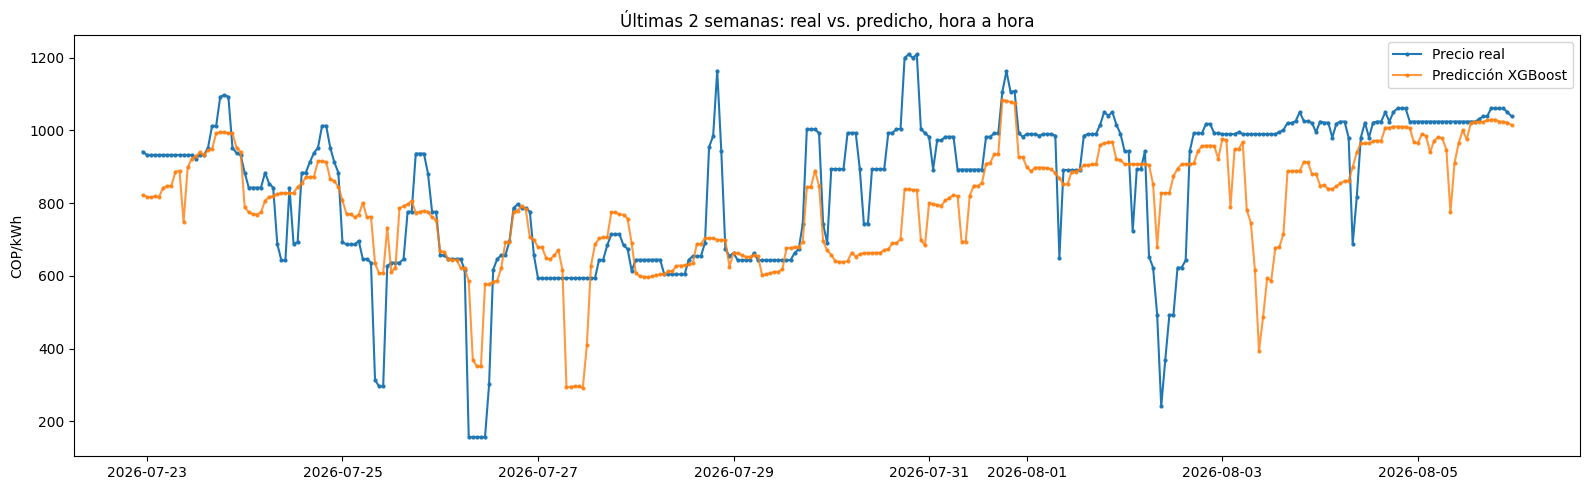

In [16]:
# --- Gráfica: zoom a las últimas 2 semanas, para ver el detalle hora a hora ---
ultimas_2_semanas = comparacion[
    comparacion["fecha_hora"] >= comparacion["fecha_hora"].max() - pd.Timedelta(days=14)
]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ultimas_2_semanas["fecha_hora"], ultimas_2_semanas["precio_bolsa"], label="Precio real", marker="o", markersize=2)
ax.plot(ultimas_2_semanas["fecha_hora"], ultimas_2_semanas["prediccion"], label="Predicción XGBoost", marker="o", markersize=2, alpha=0.8)
ax.set_title("Últimas 2 semanas: real vs. predicho, hora a hora")
ax.set_ylabel("COP/kWh")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# --- Contraste concreto: un día calmado vs. uno del régimen de ONI alto ---
# Enero 2026 (ONI todavía bajo, -0.4) contra julio 2026 (ONI ya en 1.4) --
# el mismo tipo de comparación que ya hiciste con el error agregado, pero
# ahora en un día puntual, con números que se puedan leer directamente.
dia_calmado = comparacion[comparacion["fecha_hora"].dt.date == pd.Timestamp("2026-01-15").date()]
dia_dificil = comparacion[comparacion["fecha_hora"].dt.date == pd.Timestamp("2026-07-15").date()]

print("=== 15 de enero de 2026 (ONI bajo) ===")
print(dia_calmado[["fecha_hora", "precio_bolsa", "prediccion", "error_pct"]].to_string(index=False))

print("\n=== 15 de julio de 2026 (ONI alto) ===")
print(dia_dificil[["fecha_hora", "precio_bolsa", "prediccion", "error_pct"]].to_string(index=False))

=== 15 de enero de 2026 (ONI bajo) ===
         fecha_hora  precio_bolsa  prediccion  error_pct
2026-01-15 00:00:00     111.95694  113.807030   1.652501
2026-01-15 01:00:00     111.95694  113.717621   1.572641
2026-01-15 02:00:00     111.95694  112.587646   0.563347
2026-01-15 03:00:00     111.95694  112.020271   0.056568
2026-01-15 04:00:00     111.95694  112.437592   0.429318
2026-01-15 05:00:00     111.95694  119.319588   6.576321
2026-01-15 06:00:00     117.54694  113.209213   3.690208
2026-01-15 07:00:00     117.54694  113.778046   3.206289
2026-01-15 08:00:00     117.54694  114.711876   2.411857
2026-01-15 09:00:00     111.95694  114.188065   1.992842
2026-01-15 10:00:00     117.54694  115.425827   1.804482
2026-01-15 11:00:00     117.54694  121.449615   3.320100
2026-01-15 12:00:00     117.54694  131.082428  11.514964
2026-01-15 13:00:00     119.09994  117.369438   1.452983
2026-01-15 14:00:00     190.55694  154.618881  18.859486
2026-01-15 15:00:00     190.55694  157.283997  17

In [18]:
# --- Entrenar 3 modelos XGBoost, uno por cuantil (10%, 50%, 90%) ---
cuantiles = [0.1, 0.5, 0.9]    
modelos_cuantil = {}

for q in cuantiles:
    m = xgb.XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=500,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
    m.fit(X_train, y_train)
    modelos_cuantil[q] = m
    print(f"Cuantil {q} entrenado.")

Cuantil 0.1 entrenado.


Cuantil 0.5 entrenado.


Cuantil 0.9 entrenado.


In [19]:
# --- Predecir los tres cuantiles sobre 2026 y evaluar calibración ---
predicciones_q = {q: np.exp(modelos_cuantil[q].predict(X_test)) for q in cuantiles}

comparacion["q10"] = predicciones_q[0.1]
comparacion["q50"] = predicciones_q[0.5]
comparacion["q90"] = predicciones_q[0.9]

# Calibración: si el modelo está bien calibrado, el precio real debería caer
# DENTRO del rango [q10, q90] aproximadamente el 80% de las veces -- ni más
# ni menos. Muy por debajo de 80% significa que las bandas son demasiado
# angostas (exceso de falsa confianza); muy por encima, demasiado anchas
# (inútiles para decidir).
dentro_del_rango = (comparacion["precio_bolsa"] >= comparacion["q10"]) & (comparacion["precio_bolsa"] <= comparacion["q90"])
print(f"Cobertura real: {dentro_del_rango.mean()*100:.1f}% (objetivo: ~80%)")

# El cuantil 50% como nuevo "punto medio" -- comparado con el modelo puntual anterior
calcular_metricas(comparacion["precio_bolsa"], comparacion["q50"], "XGBoost cuantil 50% (mediana)")
print("Referencia -- XGBoost puntual anterior: MAE 61.49 | RMSE 106.73 | MAPE 15.82%")

Cobertura real: 80.1% (objetivo: ~80%)
XGBoost cuantil 50% (mediana) MAE:    59.83  RMSE:   109.88  MAPE:  16.07%
Referencia -- XGBoost puntual anterior: MAE 61.49 | RMSE 106.73 | MAPE 15.82%


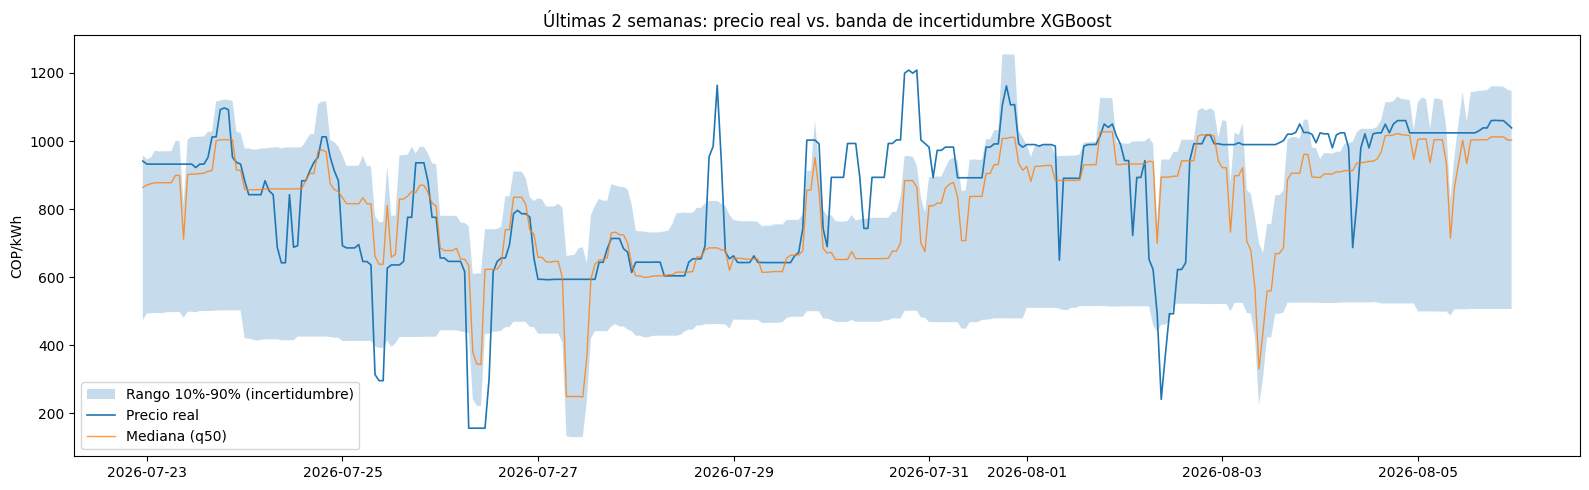

In [20]:
# --- Visualizar la banda de incertidumbre justo en el período difícil ---
ultimas_2_semanas_q = comparacion[
    comparacion["fecha_hora"] >= comparacion["fecha_hora"].max() - pd.Timedelta(days=14)
]

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(ultimas_2_semanas_q["fecha_hora"], ultimas_2_semanas_q["q10"], ultimas_2_semanas_q["q90"],
                 alpha=0.25, label="Rango 10%-90% (incertidumbre)")
ax.plot(ultimas_2_semanas_q["fecha_hora"], ultimas_2_semanas_q["precio_bolsa"], label="Precio real", linewidth=1.2)
ax.plot(ultimas_2_semanas_q["fecha_hora"], ultimas_2_semanas_q["q50"], label="Mediana (q50)", linewidth=1, alpha=0.8)
ax.set_title("Últimas 2 semanas: precio real vs. banda de incertidumbre XGBoost")
ax.set_ylabel("COP/kWh")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
# --- Construir features para el horizonte de 72h (el "peor caso" del rango prometido) ---
# Misma lógica que el horizonte de 24h, pero shift(72) en vez de shift(24) --
# simula estar parado 72 horas antes del objetivo, sin nada más fresco disponible.

def construir_features_horizonte(df_base, horizonte_horas):
    df = df_base.copy()
    df["precio_lag24h"] = df["precio_bolsa"].shift(horizonte_horas)  # sobrescribe la columna existente, no crea una nueva
    df["precio_lag168h"] = df["precio_bolsa"].shift(168)  # siempre válido, 168h > 72h
    df["precio_media_24h"] = df["precio_bolsa"].shift(horizonte_horas).rolling(window=24).mean()
    df["precio_media_7d"] = df["precio_bolsa"].shift(horizonte_horas).rolling(window=24 * 7).mean()
    df["precio_media_30d"] = df["precio_bolsa"].shift(horizonte_horas).rolling(window=24 * 30).mean()
    return df

In [22]:
# --- Armar train/test para el escenario de 72h ---
df_completo_h72 = pd.concat([
    df_train.assign(conjunto="train"), df_test.assign(conjunto="test")
]).sort_values("fecha_hora").reset_index(drop=True)

df_completo_h72 = construir_features_horizonte(df_completo_h72, horizonte_horas=72)

df_train_h72 = df_completo_h72[df_completo_h72["conjunto"] == "train"].dropna(
    subset=["precio_lag24h", "precio_lag168h", "precio_media_30d"]
).reset_index(drop=True)
df_test_h72 = df_completo_h72[df_completo_h72["conjunto"] == "test"].reset_index(drop=True)

print(f"Train (h=72h): {df_train_h72.shape} | Test (h=72h): {df_test_h72.shape}")

Train (h=72h): (59834, 43) | Test (h=72h): (5208, 43)


In [23]:
# --- Reentrenar XGBoost sobre el escenario de 72h, y comparar los dos extremos ---
X_train_h72 = df_train_h72[columnas_features]
y_train_h72 = np.log(df_train_h72["precio_bolsa"])
X_test_h72 = df_test_h72[columnas_features]
y_test_h72 = df_test_h72["precio_bolsa"]

modelo_h72 = xgb.XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8, random_state=42)
modelo_h72.fit(X_train_h72, y_train_h72)

pred_h72 = np.exp(modelo_h72.predict(X_test_h72))

print("=== Comparación honesta a lo largo del horizonte prometido ===")
calcular_metricas(y_test, y_pred_final, "XGBoost -- horizonte 24h (mejor caso)")
calcular_metricas(y_test_h72, pred_h72, "XGBoost -- horizonte 72h (peor caso)")
calcular_metricas(y_test, persistencia_test, "Persistencia (referencia)")

=== Comparación honesta a lo largo del horizonte prometido ===
XGBoost -- horizonte 24h (mejor caso) MAE:    60.66  RMSE:   107.18  MAPE:  15.81%
XGBoost -- horizonte 72h (peor caso) MAE:    82.18  RMSE:   128.81  MAPE:  23.37%
Persistencia (referencia) MAE:    56.31  RMSE:   112.22  MAPE:  15.75%


(np.float64(56.308405618279565),
 np.float64(112.22281657799465),
 np.float64(15.75262665117942))

In [24]:
# --- Persistencia correcta para el horizonte de 72h -- misma regla, sin trampa ---
serie_precio["persistencia_72h"] = serie_precio["precio_bolsa"].shift(72)
persistencia_72h_test = serie_precio[
    serie_precio["fecha_hora"].isin(df_test_h72["fecha_hora"])
]["persistencia_72h"].values

print("=== Comparación justa, cada modelo contra SU persistencia correspondiente ===")
calcular_metricas(y_test, y_pred_final, "XGBoost -- horizonte 24h")
calcular_metricas(y_test, persistencia_test, "Persistencia -- horizonte 24h")
print()
calcular_metricas(y_test_h72, pred_h72, "XGBoost -- horizonte 72h")
calcular_metricas(y_test_h72, persistencia_72h_test, "Persistencia -- horizonte 72h")

=== Comparación justa, cada modelo contra SU persistencia correspondiente ===
XGBoost -- horizonte 24h  MAE:    60.66  RMSE:   107.18  MAPE:  15.81%
Persistencia -- horizonte 24h MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

XGBoost -- horizonte 72h  MAE:    82.18  RMSE:   128.81  MAPE:  23.37%
Persistencia -- horizonte 72h MAE:    94.32  RMSE:   157.03  MAPE:  26.87%


(np.float64(94.32485258832565),
 np.float64(157.0261143915978),
 np.float64(26.873540261373606))

In [25]:
# --- Benchmark adicional: misma hora de la semana pasada ---
serie_precio["naive_168h"] = serie_precio["precio_bolsa"].shift(168)
naive_168_test = serie_precio[serie_precio["fecha_hora"].isin(df_test["fecha_hora"])]["naive_168h"].values
calcular_metricas(y_test, naive_168_test, "Naive estacional (t-168h)")

Naive estacional (t-168h) MAE:   124.53  RMSE:   180.60  MAPE:  36.75%


(np.float64(124.52600196236558),
 np.float64(180.59709508850193),
 np.float64(36.74533550982426))

In [26]:
# --- ¿El ancho de la banda de incertidumbre aumenta cuando el error real aumenta? ---
comparacion["ancho_banda"] = comparacion["q90"] - comparacion["q10"]
comparacion["error_abs"] = (comparacion["precio_bolsa"] - comparacion["q50"]).abs()

correlacion = comparacion["ancho_banda"].corr(comparacion["error_abs"])
print(f"Correlación entre ancho de banda y error real: {correlacion:.3f}")

# Agrupando en terciles de ancho -- misma idea de "confianza baja/media/alta"
# que encontramos en la literatura hace un rato
comparacion["confianza"] = pd.qcut(comparacion["ancho_banda"], q=3, labels=["Alta", "Media", "Baja"])
print(comparacion.groupby("confianza", observed=True)["error_abs"].mean())

Correlación entre ancho de banda y error real: 0.410
confianza
Alta      19.408388
Media     53.351515
Baja     106.726937
Name: error_abs, dtype: float64


In [27]:
# --- Corrección de Duan, probada contra 2025 (NO contra 2026 todavía) ---
modelo_valid = xgb.XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.01,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42)
modelo_valid.fit(X_train_gs, y_train_gs)

residuos_log = y_train_gs.values - modelo_valid.predict(X_train_gs)
factor_smearing = np.mean(np.exp(residuos_log))
print("Factor de smearing:", factor_smearing)

pred_valid_sin = np.exp(modelo_valid.predict(X_valid_gs))
pred_valid_con = pred_valid_sin * factor_smearing

calcular_metricas(y_valid_gs.values, pred_valid_sin, "Sin corrección (valid. 2025)")
calcular_metricas(y_valid_gs.values, pred_valid_con, "Con Duan (valid. 2025)")

Factor de smearing: 1.0181520486064324
Sin corrección (valid. 2025) MAE:    45.05  RMSE:    91.35  MAPE:  17.97%
Con Duan (valid. 2025)    MAE:    45.56  RMSE:    91.17  MAPE:  18.79%


(np.float64(45.555907874081534),
 np.float64(91.17129079659932),
 np.float64(18.78800598232025))

In [28]:
# --- Reconstruir 72h con TODAS las variables correctamente rezagadas ---
df_maestro_train = pd.read_csv(RAIZ / "data" / "processed" / "dataset_maestro_2019_2025.csv", parse_dates=["fecha_hora"])
df_maestro_test = pd.read_csv(RAIZ / "data" / "processed" / "dataset_maestro_2026.csv", parse_dates=["fecha_hora"])

df_h72 = pd.concat([df_maestro_train.assign(conjunto="train"), df_maestro_test.assign(conjunto="test")]
                    ).sort_values("fecha_hora").reset_index(drop=True)

H72 = 72
df_h72["precio_lag24h"] = df_h72["precio_bolsa"].shift(H72)
df_h72["precio_lag168h"] = df_h72["precio_bolsa"].shift(168)
df_h72["precio_media_24h"] = df_h72["precio_bolsa"].shift(H72).rolling(24).mean()
df_h72["precio_media_7d"] = df_h72["precio_bolsa"].shift(H72).rolling(24*7).mean()
df_h72["precio_media_30d"] = df_h72["precio_bolsa"].shift(H72).rolling(24*30).mean()

for col in ["volumen_embalses", "aportes_hidricos"]:
    base = df_h72[col].shift(H72)
    df_h72[col] = base
    df_h72[f"{col}_delta_1d"] = base.diff(24)
    df_h72[f"{col}_delta_7d"] = base.diff(24*7)
    df_h72[f"{col}_media_7d"] = base.rolling(24*7).mean()
    df_h72[f"{col}_media_30d"] = base.rolling(24*30).mean()
    df_h72[f"{col}_vs_media30d"] = base / base.rolling(24*30).mean()

precio_base_72 = df_h72["precio_bolsa"].shift(H72)
df_h72["precio_std_24h"] = precio_base_72.rolling(24).std()
df_h72["precio_std_7d"] = precio_base_72.rolling(24*7).std()
df_h72["precio_rango_24h"] = precio_base_72.rolling(24).max() - precio_base_72.rolling(24).min()
df_h72["ratio_volatilidad"] = df_h72["precio_std_24h"] / df_h72["precio_std_7d"]

df_h72["demanda_lag24h"] = df_h72["demanda"].shift(H72)
df_h72["demanda_lag48h"] = df_h72["demanda"].shift(H72 + 24)
df_h72["demanda_lag72h"] = df_h72["demanda"].shift(H72 + 48)
df_h72["demanda_media_24h"] = df_h72["demanda"].shift(H72).rolling(24).mean()

df_h72["hora"] = df_h72["fecha_hora"].dt.hour
df_h72["hora_sin"] = np.sin(2*np.pi*df_h72["hora"]/24); df_h72["hora_cos"] = np.cos(2*np.pi*df_h72["hora"]/24)
df_h72["dia_semana"] = df_h72["fecha_hora"].dt.dayofweek
df_h72["dia_semana_sin"] = np.sin(2*np.pi*df_h72["dia_semana"]/7); df_h72["dia_semana_cos"] = np.cos(2*np.pi*df_h72["dia_semana"]/7)
df_h72["dia_anio"] = df_h72["fecha_hora"].dt.dayofyear
df_h72["dia_anio_sin"] = np.sin(2*np.pi*df_h72["dia_anio"]/365.25); df_h72["dia_anio_cos"] = np.cos(2*np.pi*df_h72["dia_anio"]/365.25)

df_train_h72c = df_h72[df_h72["conjunto"]=="train"].dropna(subset=columnas_features).reset_index(drop=True)
df_test_h72c = df_h72[df_h72["conjunto"]=="test"].reset_index(drop=True)

modelo_h72c = xgb.XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.01,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42)
modelo_h72c.fit(df_train_h72c[columnas_features], np.log(df_train_h72c["precio_bolsa"]))
pred_h72c = np.exp(modelo_h72c.predict(df_test_h72c[columnas_features]))

calcular_metricas(df_test_h72c["precio_bolsa"].values, pred_h72c, "XGBoost 72h (todo correctamente rezagado)")
print("Referencia -- 72h con hidrología a 24h: MAE 82.18 | RMSE 128.81 | MAPE 23.37%")

XGBoost 72h (todo correctamente rezagado) MAE:    89.56  RMSE:   144.06  MAPE:  24.40%
Referencia -- 72h con hidrología a 24h: MAE 82.18 | RMSE 128.81 | MAPE 23.37%
